In [3]:
# BASIC LIBRARIES
import pandas as pd
import numpy as np


# DATA VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns

# DATA PREPROCESSING
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

# LINEAR MODELS
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

# TREE-BASED REGRESSION
from sklearn.tree import DecisionTreeRegressor

# ENSEMBLE LEARNING METHODS
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import BaggingRegressor

# KNN REGRESSION
from sklearn.neighbors import KNeighborsRegressor

# SUPPORT VECTOR REGRESSION
from sklearn.svm import SVR

# XGBOOST REGRESSION
from xgboost import XGBRegressor

# LIGHTGBM REGRESSION
from lightgbm import LGBMRegressor

# CATBOOST REGRESSION
from catboost import CatBoostRegressor

# CROSS VALIDATION
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

# HYPERPARAMETER TUNING
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

# REGRESSION PERFORMANCE METRICS
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    explained_variance_score,
    max_error
)

# MODEL SAVING
import joblib
import pickle

# WARNINGS
import warnings
warnings.filterwarnings("ignore")

In [4]:
df=pd.read_excel("Medical_Insurance_Cost_Prediction.xlsm")
df.shape

(1338, 7)

In [5]:
# Create Backup Copy
df_copy = df.copy()

In [6]:
# First 5 Records
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
# Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [8]:
# Statistical Summary
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [9]:
# Check Datatypes
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [10]:
# Missing Values Percentage
(df.isnull().sum() / len(df)) * 100

age         0.0
sex         0.0
bmi         0.0
children    0.0
smoker      0.0
region      0.0
charges     0.0
dtype: float64

In [11]:
# Duplicate Records
df.duplicated().sum()

np.int64(1)

In [12]:
df = df.drop_duplicates()

In [13]:
# Separate Numerical and Categorical Columns
num_cols = df.select_dtypes(include=["int64","float64"]).columns
cat_cols = df.select_dtypes(include=["object","string"]).columns

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
Index(['age', 'bmi', 'children', 'charges'], dtype='str')

Categorical Columns:
Index(['sex', 'smoker', 'region'], dtype='str')


# Univariate EDA

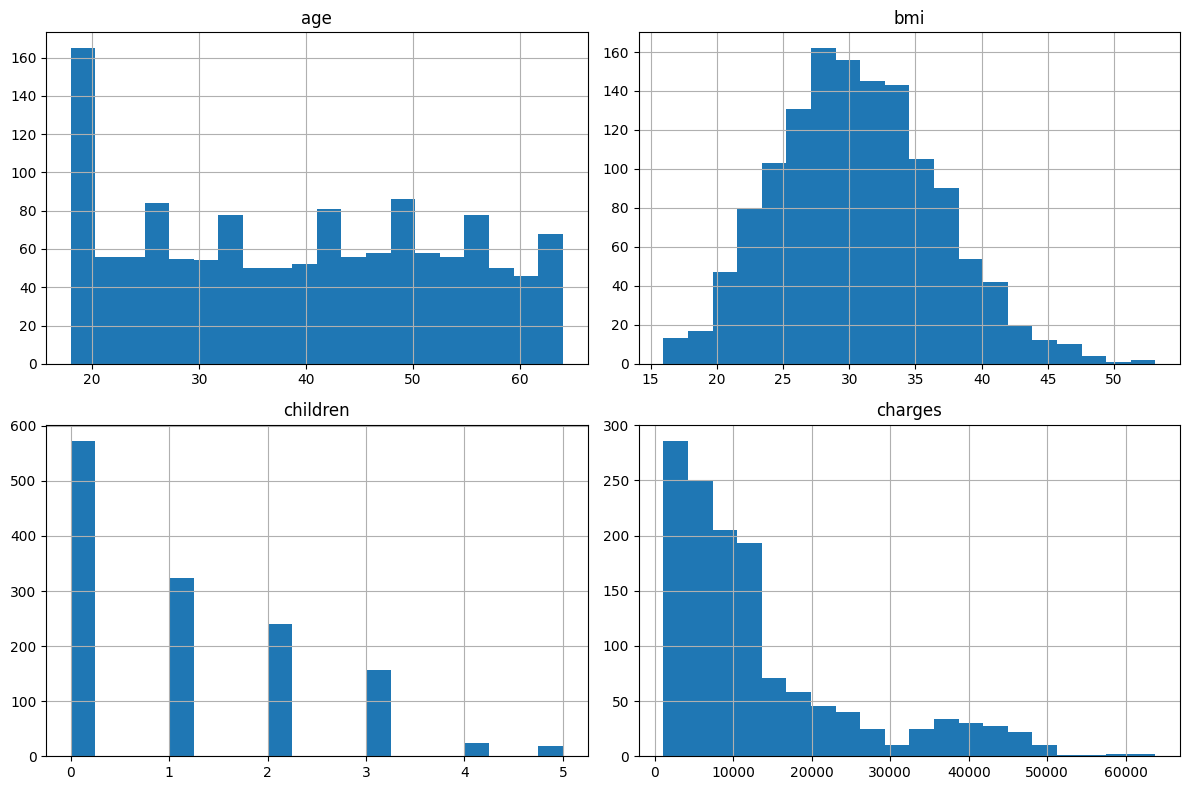

In [14]:
# Distribution of Numerical Features

df[num_cols].hist(figsize=(12,8), bins=20)

plt.tight_layout()
plt.show()

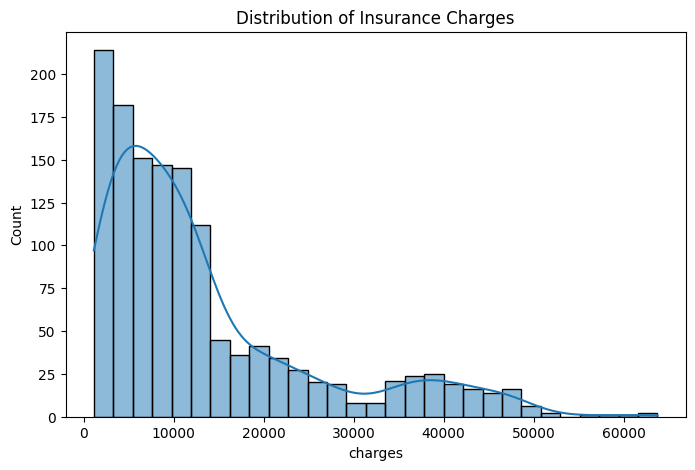

In [15]:
# Target Variable Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["charges"], kde=True)

plt.title("Distribution of Insurance Charges")
plt.show()

# Correlation Analysis

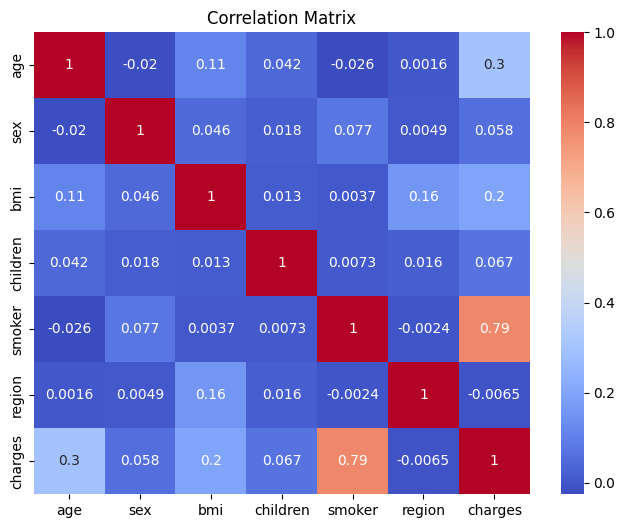

In [16]:
# Convert categorical columns temporarily for correlation analysis

df_corr = df.copy()

df_corr["sex"] = df_corr["sex"].map({"male":1,"female":0})
df_corr["smoker"] = df_corr["smoker"].map({"yes":1,"no":0})

df_corr["region"] = df_corr["region"].map({
    "northeast":0,
    "northwest":1,
    "southeast":2,
    "southwest":3
})

corr_matrix = df_corr.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

### The correlation matrix shows that the smoker feature has the strongest positive correlation with insurance charges (0.79), indicating that smoking status is the most influential factor affecting medical insurance costs. Age (0.30) and BMI (0.20) have moderate positive correlations with charges. The region, sex, and children features have very weak correlations with the target variable.

# Outlier Detection

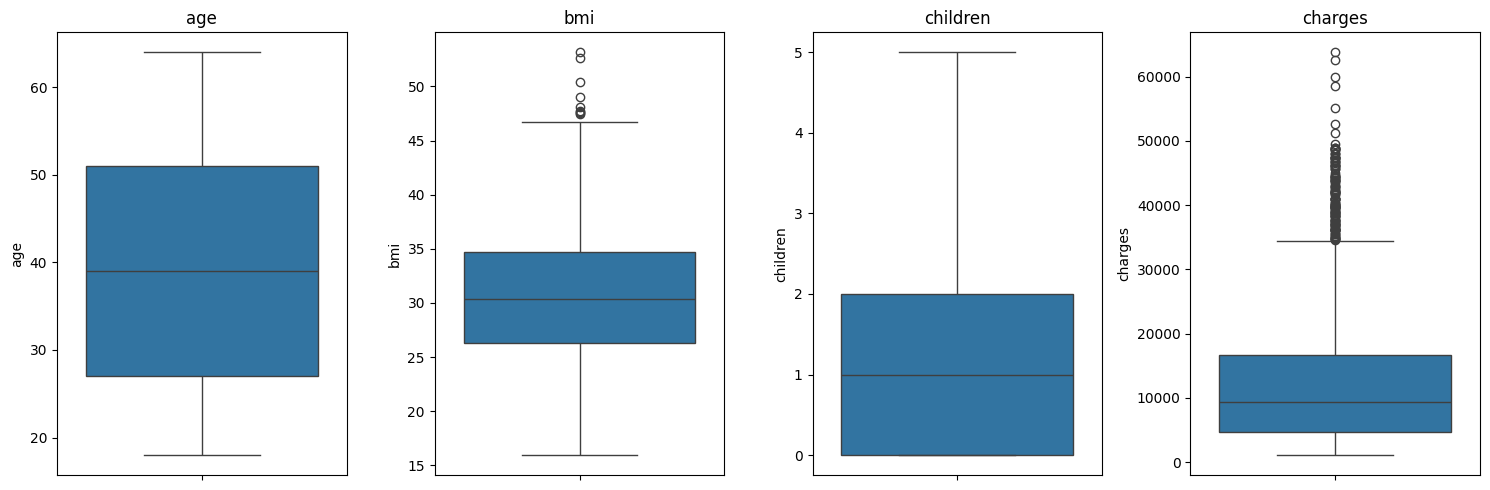

In [17]:
# Numerical Features Boxplots

plt.figure(figsize=(15,5))

for i,col in enumerate(num_cols,1):

    plt.subplot(1,4,i)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()
plt.show()

### Boxplots were used to detect outliers in numerical features. The BMI feature contains a few high-value outliers. The Charges variable contains several extreme observations. However, these values represent real-world medical expenses and are not data-entry errors. Therefore, outliers were retained for model training to preserve important business information.

# check skewness.

In [18]:
for col in ["age","bmi","children"]:
    print(col, ":", df[col].skew())

age : 0.054780773126998195
bmi : 0.28391419385321137
children : 0.9374206440474123


### Skewness analysis was performed on numerical features. The skewness values for age (0.05), BMI (0.28), and children (0.94) were within acceptable limits. Therefore, no feature transformation was required.

## Feature Encoding

In [19]:
df_encoded = pd.get_dummies(
    df,
    columns=["sex", "smoker", "region"],
    drop_first=True,
    dtype=int
)

df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


## Split X and y

In [20]:
X = df_encoded.drop("charges", axis=1)

y = df_encoded["charges"]

print(X.shape)
print(y.shape)

(1337, 8)
(1337,)


## Train Test Split

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1069, 8)
(268, 8)


## Feature Scaling

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

#### Feature encoding was performed using One-Hot Encoding with get_dummies(). Dummy variable trap was avoided using drop_first=True. Feature scaling was performed using StandardScaler. Separate scaled datasets were created for scale-sensitive algorithms such as Linear Regression, KNN, SVR, Ridge, Lasso, and ElasticNet, while tree-based models were trained using the original unscaled features.

### Regression

#### Train All Scaled Models

In [23]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

scaled_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR()
}

trained_scaled_models = {}

for name, model in scaled_models.items():

    model.fit(X_train_scaled, y_train)

    trained_scaled_models[name] = model

    print(f"{name} Trained Successfully")

Linear Regression Trained Successfully
Ridge Trained Successfully
Lasso Trained Successfully
ElasticNet Trained Successfully
KNN Trained Successfully
SVR Trained Successfully


### Create Evaluation Function

In [24]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np


def evaluate_model(model, X_train_data, X_test_data,
                   y_train_data, y_test_data):

    # Predictions

    y_train_pred = model.predict(X_train_data)
    y_test_pred = model.predict(X_test_data)

    # Metrics

    train_r2 = r2_score(y_train_data, y_train_pred)
    test_r2 = r2_score(y_test_data, y_test_pred)

    mae = mean_absolute_error(y_test_data, y_test_pred)

    mse = mean_squared_error(y_test_data, y_test_pred)

    rmse = np.sqrt(mse)

    # Adjusted R2

    n = X_test_data.shape[0]
    p = X_test_data.shape[1]

    adjusted_r2 = (
        1 - ((1 - test_r2) * (n - 1))
        / (n - p - 1)
    )

    return (
        train_r2,
        test_r2,
        mae,
        mse,
        rmse,
        adjusted_r2
    )

### Evaluate All Models

In [25]:
results = []

for name, model in trained_scaled_models.items():

    train_r2, test_r2, mae, mse, rmse, adjusted_r2 = evaluate_model(
        model,
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test
    )

    results.append([
        name,
        train_r2,
        test_r2,
        mae,
        mse,
        rmse,
        adjusted_r2
    ])

### Create Comparison Table

In [26]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Train R2",
        "Test R2",
        "MAE",
        "MSE",
        "RMSE",
        "Adjusted R2"
    ]
)

results_df

,Model,Train R2,Test R2,MAE,MSE,RMSE,Adjusted R2
0,Linear Regression,0.729906,0.806929,4177.045561,3.547802e+07,5956.342894,0.800965
1,Ridge,0.729905,0.806741,4179.621622,3.551247e+07,5959.234416,0.800772
2,Lasso,0.729906,0.806889,4177.213780,3.548536e+07,5956.959371,0.800924
3,ElasticNet,0.646887,0.670078,5522.931419,6.062514e+07,7786.214475,0.659888
4,KNN,0.850476,0.837123,3474.067731,2.992960e+07,5470.795560,0.832092
5,SVR,-0.097935,-0.131161,9264.975876,2.078577e+08,14417.272277,-0.166101


### Sort by Best Test R²

In [27]:
results_df.sort_values(
    by="Test R2",
    ascending=False
)

,Model,Train R2,Test R2,MAE,MSE,RMSE,Adjusted R2
4,KNN,0.850476,0.837123,3474.067731,2.992960e+07,5470.795560,0.832092
0,Linear Regression,0.729906,0.806929,4177.045561,3.547802e+07,5956.342894,0.800965
2,Lasso,0.729906,0.806889,4177.213780,3.548536e+07,5956.959371,0.800924
1,Ridge,0.729905,0.806741,4179.621622,3.551247e+07,5959.234416,0.800772
3,ElasticNet,0.646887,0.670078,5522.931419,6.062514e+07,7786.214475,0.659888
5,SVR,-0.097935,-0.131161,9264.975876,2.078577e+08,14417.272277,-0.166101


## Regression
### Train Tree Models

In [28]:
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    ExtraTreesRegressor
)

tree_models = {

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Random Forest": RandomForestRegressor(random_state=42),

    "Gradient Boosting": GradientBoostingRegressor(random_state=42),

    "AdaBoost": AdaBoostRegressor(random_state=42),

    "Extra Trees": ExtraTreesRegressor(random_state=42)

}

trained_tree_models = {}

for name, model in tree_models.items():

    model.fit(X_train, y_train)

    trained_tree_models[name] = model

    print(f"{name} Trained Successfully")

Decision Tree Trained Successfully
Random Forest Trained Successfully
Gradient Boosting Trained Successfully
AdaBoost Trained Successfully
Extra Trees Trained Successfully


### Evaluate Tree Models

In [29]:
tree_results = []

for name, model in trained_tree_models.items():

    train_r2, test_r2, mae, mse, rmse, adjusted_r2 = evaluate_model(
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )

    tree_results.append([
        name,
        train_r2,
        test_r2,
        mae,
        mse,
        rmse,
        adjusted_r2
    ])

### Create Tree Results Table

In [30]:
tree_results_df = pd.DataFrame(
    tree_results,
    columns=[
        "Model",
        "Train R2",
        "Test R2",
        "MAE",
        "MSE",
        "RMSE",
        "Adjusted R2"
    ]
)

tree_results_df.sort_values(
    by="Test R2",
    ascending=False
)

,Model,Train R2,Test R2,MAE,MSE,RMSE,Adjusted R2
2,Gradient Boosting,0.891603,0.900856,2517.467831,1.821824e+07,4268.283018,0.897794
1,Random Forest,0.973658,0.879661,2637.994548,2.211300e+07,4702.446229,0.875944
3,AdaBoost,0.828523,0.871113,3942.575711,2.368379e+07,4866.599299,0.867132
4,Extra Trees,1.000000,0.851793,2703.081823,2.723386e+07,5218.607550,0.847216
0,Decision Tree,1.000000,0.818882,2730.629849,3.328152e+07,5769.014181,0.813288


### Best Model Selection
| Model             | Test R²    |
| ----------------- | ---------- |
| Gradient Boosting | **0.9009** |
| Random Forest     | 0.8797     |
| AdaBoost          | 0.8711     |
| Extra Trees       | 0.8518     |
| KNN               | 0.8371     |
| Decision Tree     | 0.8188     |
| Linear Regression | 0.8069     |


#### Final Winner

#####  GradientBoostingRegressor

#### Reason:

##### Highest Test R²

##### Lowest RMSE

##### No Overfitting

##### Stable train-test performance

## Hyperparameter Tuning

In [31]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

gb_model = GradientBoostingRegressor(random_state=42)

param_grid = {
    "n_estimators":[100,200,300],
    "learning_rate":[0.01,0.05,0.1],
    "max_depth":[2,3,4],
    "subsample":[0.8,1.0]
}

grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train,y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

{'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.8}
nan


### Final Model

In [32]:
best_model = grid_search.best_estimator_

### Save Model

In [33]:
import joblib

joblib.dump(
    best_model,
    "medical_insurance_model.pkl"
)

['medical_insurance_model.pkl']

### Evaluation function

In [34]:
from sklearn.metrics import mean_squared_error
import numpy as np

def evaluate_model(model,
                   X_train_data,
                   X_test_data,
                   y_train_data,
                   y_test_data):

    y_train_pred = model.predict(X_train_data)
    y_test_pred = model.predict(X_test_data)

    train_r2 = r2_score(y_train_data, y_train_pred)
    test_r2 = r2_score(y_test_data, y_test_pred)

    train_rmse = np.sqrt(
        mean_squared_error(
            y_train_data,
            y_train_pred
        )
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test_data,
            y_test_pred
        )
    )

    return (
        train_r2,
        test_r2,
        train_rmse,
        test_rmse
    )

### Overfitting

In [35]:
results = []

for name, model in trained_tree_models.items():

    train_r2, test_r2, train_rmse, test_rmse = evaluate_model(
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )

    overfit = "Yes" if (train_r2 - test_r2) > 0.10 else "No"

    results.append([
        name,
        train_rmse,
        test_rmse,
        train_r2,
        test_r2,
        overfit
    ])

# Model Comparison Table

In [36]:
comparison_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Train RMSE",
        "Test RMSE",
        "Train R²",
        "Test R²",
        "Overfitting"
    ]
)

comparison_df.sort_values(
    by="Test R²",
    ascending=False
)

,Model,Train RMSE,Test RMSE,Train R²,Test R²,Overfitting
2,Gradient Boosting,3.852413e+03,4268.283018,0.891603,0.900856,No
1,Random Forest,1.899104e+03,4702.446229,0.973658,0.879661,No
3,AdaBoost,4.845380e+03,4866.599299,0.828523,0.871113,No
4,Extra Trees,2.452010e-11,5218.607550,1.000000,0.851793,Yes
0,Decision Tree,0.000000e+00,5769.014181,1.000000,0.818882,Yes


In [37]:
import joblib

joblib.dump(best_model, "medical_insurance_model.pkl")

['medical_insurance_model.pkl']

In [38]:
joblib.dump(trained_tree_models["Gradient Boosting"],
            "medical_insurance_model.pkl")

['medical_insurance_model.pkl']

# I have added the live URL for this mini project. Click the link below to explore the application.
[Click here to visit Google](https://healthcare-insurance-cost-predictor-ml.streamlit.app/)


In [39]:
import joblib

model = joblib.load("medical_insurance_model.pkl")

print(type(model))

<class 'sklearn.ensemble._gb.GradientBoostingRegressor'>


In [40]:
joblib.dump(best_model, "medical_insurance_model.pkl")

['medical_insurance_model.pkl']